# Mohler ASAG — Exploratory Data Analysis

EDA on the cleaned corpus produced by `app/cleaning.py` (PP-76), which itself runs on the raw corpus from `app/loader.py` (PP-74), profiled by `app/profiling.py` (PP-75).

Findings so far: 95 duplicate `(question, student_answer)` rows dropped, 5 rows with leftover HTML-entity encoding artifacts fixed.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet('../data/cleaned/mohler_cleaned.parquet')
df.shape

(2347, 8)

## Overview

In [2]:
df.dtypes

id                       str
question                 str
instructor_answer        str
student_answer           str
score_grader_1       float32
score_grader_2       float32
score_avg            float32
split                    str
dtype: object

## Split balance

How many rows come from `open_ended` vs `close_ended` questions. Worth noting: the dataset's own README states the original authors "ignored responses to the closed-ended questions in all of their work" - we currently keep both splits in `loader.py`. Decide whether to match that exclusion before this feeds PP-115 splits.

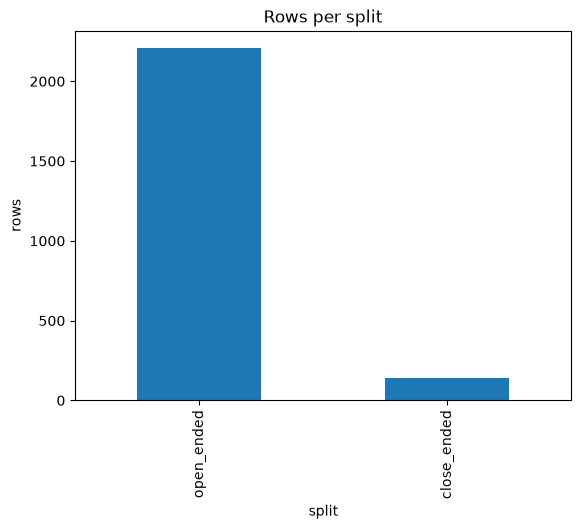

In [3]:
df['split'].value_counts().plot(kind='bar', title='Rows per split')
plt.ylabel('rows')
plt.show()

## Answer length

Word count of `student_answer` — confirms this is genuinely *short*-answer data, and gives a length baseline to compare AI-generated answers against later. If AI answers come out systematically longer or shorter, that's a shortcut a detector could exploit instead of learning real style differences.

In [4]:
word_counts = df['student_answer'].str.split().str.len()
word_counts.describe()

count    2347.000000
mean       19.047294
std        14.700850
min         1.000000
25%         9.000000
50%        16.000000
75%        25.000000
max       173.000000
Name: student_answer, dtype: float64

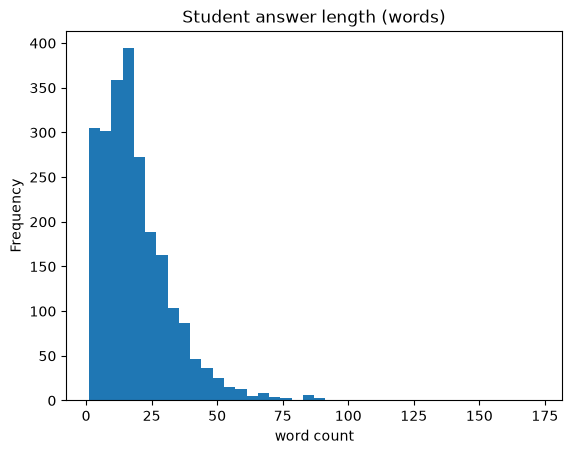

In [5]:
word_counts.plot(kind='hist', bins=40, title='Student answer length (words)')
plt.xlabel('word count')
plt.show()